# FE za dataset *Otkrivanje transakcijskih prijevara*
 https://www.kaggle.com/competitions/dap-fer2025

# 1. Ponavljanje nužnih transformacija iz prethodne bilježnice i priprema dataseta

- **VAŽNO!** - Normalizaciju i odabir značajki NE smijemo raditi na punom datasetu (leakage), smijemo samo na dijelu koji će ići u treniranje

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('dataset.csv')

# brisanje značajke Is_Contactless
del df['Is_Contactless']

# uklanjanje zapisa gdje nedostaju podaci, svi od USER_0007
df = df[df['User_ID'] != 'USER_0007'].copy()

# korekcija neujednačenog označavanja
df['Location'] = df['Location'].replace('Lndn', 'London')
df['Merchant_Category'] = df['Merchant_Category'].replace('Electronis', 'Electronics')

# izbacivanje negativnih i transakcija s iznosom 0
df = df.loc[df['Transaction_Amount'] > 0, :].copy()

# popravljanje Is_Weekend
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df['Is_Weekend'] = df["Timestamp"].dt.dayofweek >= 5

# one-hot encoding
df = pd.get_dummies(df, columns=['Transaction_Type'], prefix='TT')
df = pd.get_dummies(df, columns=['Device_Type'], prefix='DT')
df = pd.get_dummies(df, columns=['Location'], prefix='Loc')
df = pd.get_dummies(df, columns=['Merchant_Category'], prefix='MerchCat')
df = pd.get_dummies(df, columns=['Card_Type'], prefix='CT')
df = pd.get_dummies(df, columns=['Authentication_Method'], prefix='AUM')

# log transform
df['Transaction_Amount'] = np.log1p(df['Transaction_Amount'])

# date transform
df["Day"] = df["Timestamp"].dt.day
df["Month"] = df["Timestamp"].dt.month
df["Year"] = df["Timestamp"].dt.year
df["Day_of_Week"] = df["Timestamp"].dt.dayofweek
df["Quarter"] = df["Timestamp"].dt.quarter

df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)
df["DOW_sin"] = np.sin(2 * np.pi * df["Day_of_Week"] / 7)
df["DOW_cos"] = np.cos(2 * np.pi * df["Day_of_Week"] / 7)
df["Day_sin"] = np.sin(2 * np.pi * df["Day"] / 31)
df["Day_cos"] = np.cos(2 * np.pi * df["Day"] / 31)

del df['Timestamp']
del df['Day_of_Week']
del df['Day']
del df['Month']
del df['Year']
del df['Quarter']

# ekspertne značajke
df["Amount_vs_Avg7d"] = df["Transaction_Amount"] / (df["Avg_Transaction_Amount_7d"] + 1)
df["Txn_Burst"] = (df["Daily_Transaction_Count"] > 10).astype(int)
df["Weekend_Online"] = df["Is_Weekend"] * df["TT_Online"]

# ============================================================
# PRVO SPLIT, TEK ONDA SCALING
# ============================================================

y = df["Fraud_Label"].copy()
X = df.drop(columns=['Transaction_ID', 'User_ID', 'Fraud_Label']).copy()

# bool -> int
bool_cols = X.select_dtypes(include=['bool']).columns
X.loc[:, bool_cols] = X.loc[:, bool_cols].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================================
# Z-SCORE SCALING (fit samo na train)
# ============================================================

zz_scale_cols = [
    'Transaction_Amount',
    'Account_Balance',
    'Daily_Transaction_Count',
    'Avg_Transaction_Amount_7d',
    'Failed_Transaction_Count_7d',
    'Card_Age',
    'Transaction_Distance',
    'Amount_vs_Avg7d'
]

zscaler = StandardScaler()

X_train_zz = X_train.copy()
X_test_zz = X_test.copy()

X_train_zz[zz_scale_cols] = zscaler.fit_transform(X_train[zz_scale_cols])
X_test_zz[zz_scale_cols] = zscaler.transform(X_test[zz_scale_cols])

# ============================================================
# MIN-MAX SCALING (fit samo na train)
# dodajemo i sinus/cosinus datum zbog chi2
# ============================================================

mm_scale_cols = [
    'Transaction_Amount',
    'Account_Balance',
    'Daily_Transaction_Count',
    'Avg_Transaction_Amount_7d',
    'Failed_Transaction_Count_7d',
    'Card_Age',
    'Transaction_Distance',
    'Amount_vs_Avg7d',
    'Month_sin',
    'Month_cos',
    'DOW_sin',
    'DOW_cos',
    'Day_sin',
    'Day_cos'
]

mmscaler = MinMaxScaler()

X_train_mm = X_train.copy()
X_test_mm = X_test.copy()

X_train_mm[mm_scale_cols] = mmscaler.fit_transform(X_train[mm_scale_cols])
X_test_mm[mm_scale_cols] = mmscaler.transform(X_test[mm_scale_cols])

# ============================================================
# PROVJERA
# ============================================================

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("\nZ-score train info:")
print(X_train_zz.info())

print("\nMin-max train info:")
print(X_train_mm.info())

Train shape: (39998, 45)
Test shape : (10000, 45)

Z-score train info:
<class 'pandas.core.frame.DataFrame'>
Index: 39998 entries, 30137 to 40987
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_Amount            39998 non-null  float64
 1   Account_Balance               39998 non-null  float64
 2   IP_Address_Flag               39998 non-null  float64
 3   Previous_Fraudulent_Activity  39998 non-null  float64
 4   Daily_Transaction_Count       39998 non-null  float64
 5   Avg_Transaction_Amount_7d     39998 non-null  float64
 6   Failed_Transaction_Count_7d   39998 non-null  float64
 7   Card_Age                      39998 non-null  float64
 8   Transaction_Distance          39998 non-null  float64
 9   Risk_Score                    39998 non-null  float64
 10  Is_Weekend                    39998 non-null  int64  
 11  TT_ATM Withdrawal             39998 non-null  int

C:\Users\Nikolina\AppData\Local\Temp\ipykernel_7236\841969274.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 1]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X.loc[:, bool_cols] = X.loc[:, bool_cols].astype(int)
C:\Users\Nikolina\AppData\Local\Temp\ipykernel_7236\841969274.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X.loc[:, bool_cols] = X.loc[:, bool_cols].astype(int)
C:\Users\Nikolina\AppData\Local\Temp\ipykernel_7236\841969274.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 1 0 ... 0 1 1]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X.loc[:, b

# 2. Rangiranje značajki - SelectKBest
- Mjere:
    1. **f_classif (ANOVA F)**
    2. **mutual_info_classif**
    3. **chi2**


=== ANOVA F ===
Failed_Transaction_Count_7d    14305.320607
Risk_Score                      6890.975908
Daily_Transaction_Count            2.492517
Loc_New York                       2.486704
AUM_PIN                            2.029033
Day_sin                            1.958868
MerchCat_Restaurants               1.853223
DT_Tablet                          1.681881
Avg_Transaction_Amount_7d          1.637670
CT_Discover                        1.440758
Txn_Burst                          1.319451
Amount_vs_Avg7d                    1.192470
Weekend_Online                     1.031987
TT_POS                             1.005316
AUM_OTP                            0.927213
dtype: float64
Odabrani: ['Failed_Transaction_Count_7d', 'Risk_Score', 'Daily_Transaction_Count', 'Loc_New York', 'AUM_PIN', 'Day_sin', 'MerchCat_Restaurants', 'DT_Tablet', 'Avg_Transaction_Amount_7d', 'CT_Discover']

=== Mutual Information ===
Failed_Transaction_Count_7d     0.288536
Risk_Score                      0.200

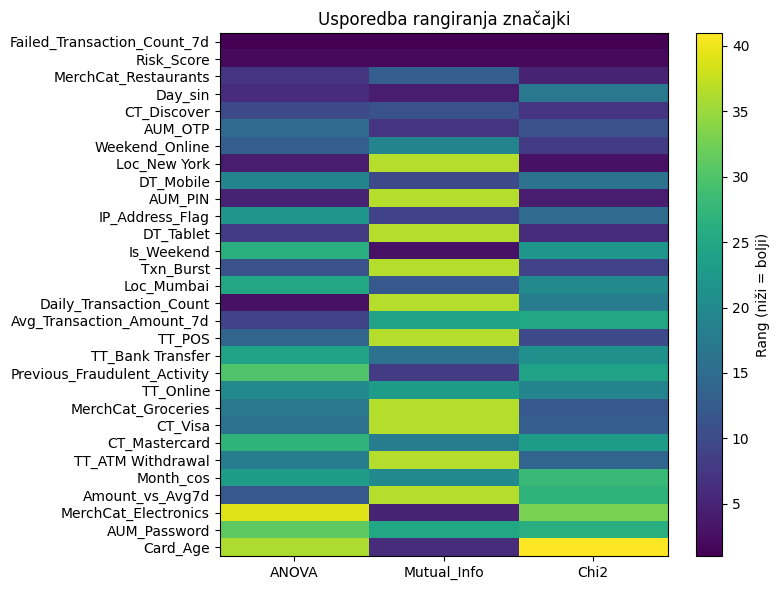

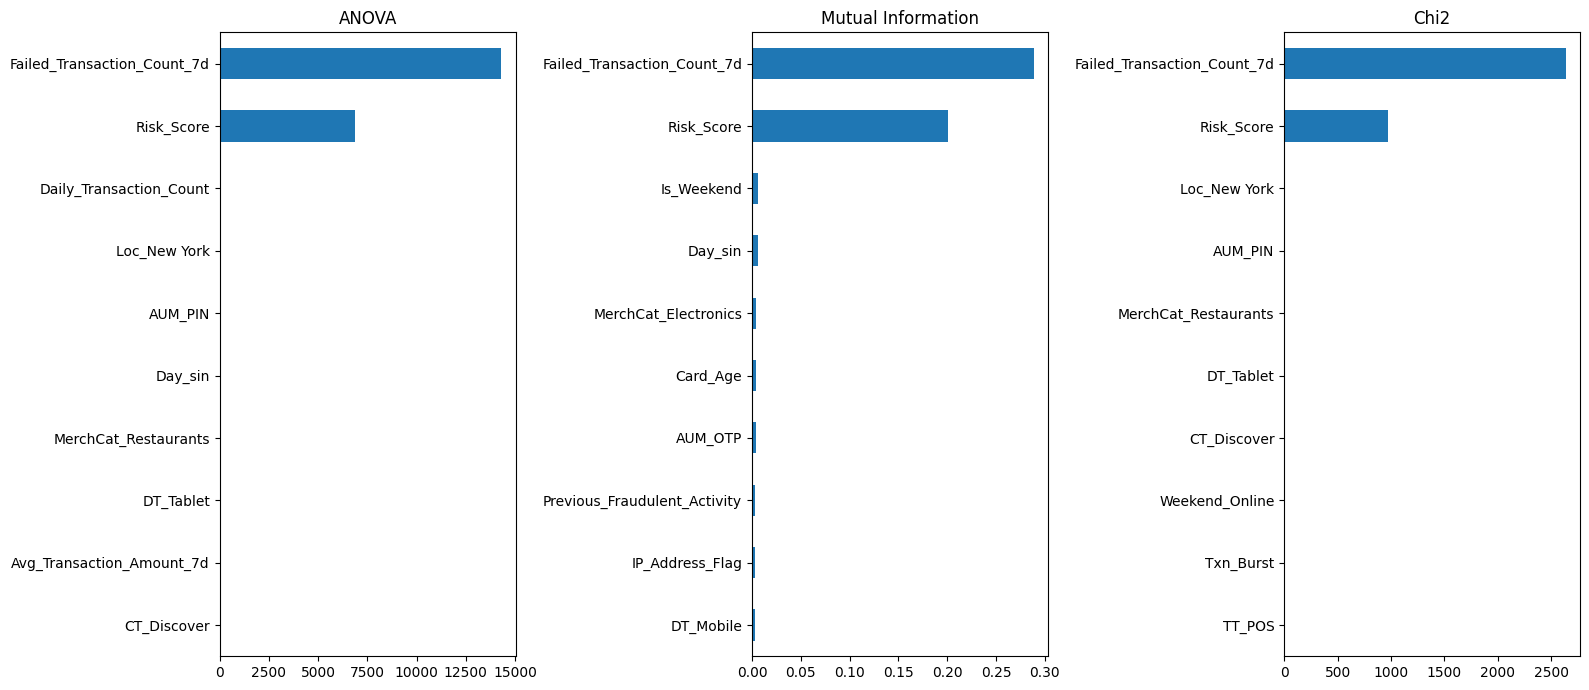

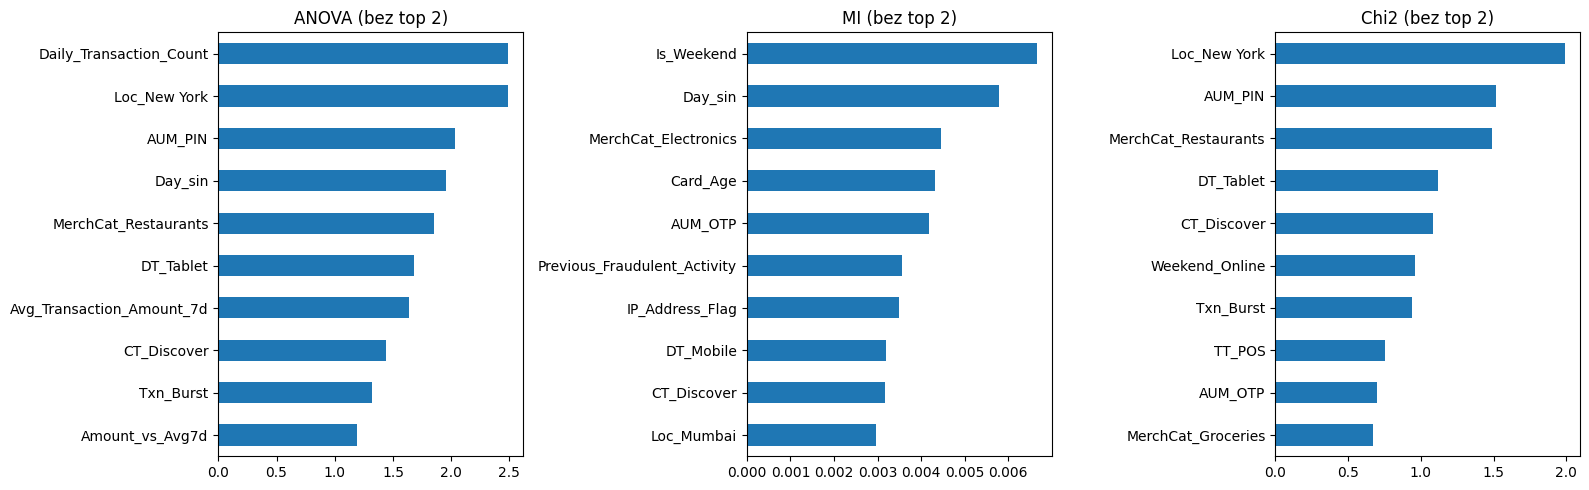

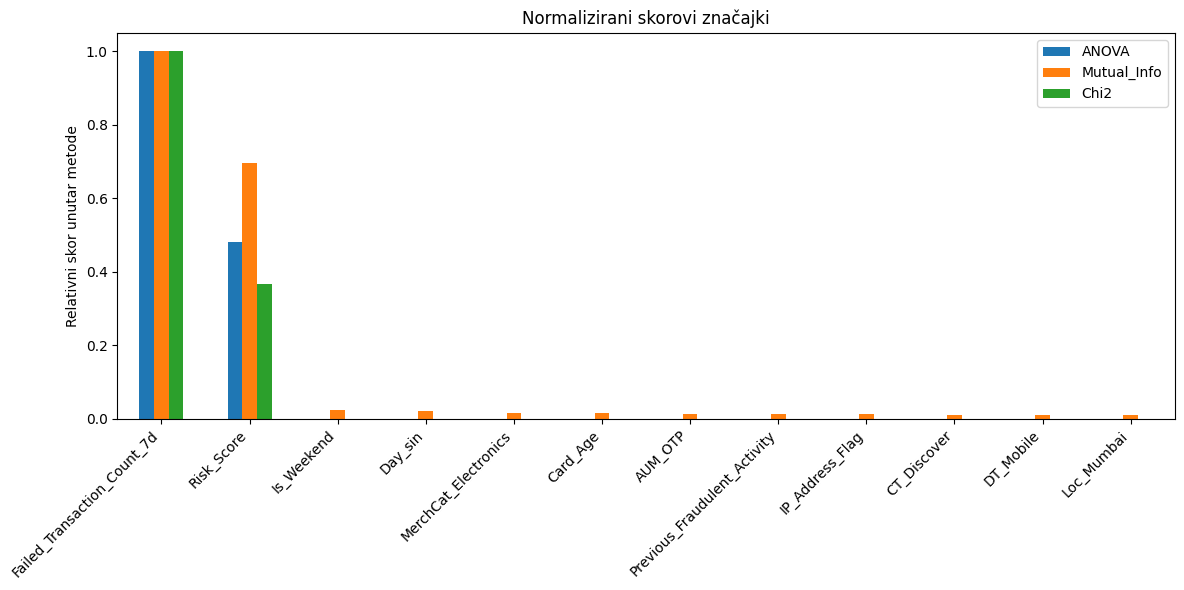

In [4]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2

# -----------------------------------------------------
# RUN
#-----------------------------------------------------

def run_kbest(X, y, score_func, k=10):
    selector = SelectKBest(score_func=score_func, k=k)
    selector.fit(X, y)

    scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
    selected = scores.index[:k].tolist()

    return scores, selected


k = 10

anova_scores, anova_sel = run_kbest(X_train_zz, y_train, f_classif, k)
mi_scores, mi_sel = run_kbest(X_train_zz, y_train, mutual_info_classif, k)
chi2_scores, chi2_sel = run_kbest(X_train_mm, y_train, chi2, k)


print("\n=== ANOVA F ===")
print(anova_scores.head(15))
print("Odabrani:", anova_sel)

print("\n=== Mutual Information ===")
print(mi_scores.head(15))
print("Odabrani:", mi_sel)

print("\n=== Chi2 ===")
print(chi2_scores.head(15))
print("Odabrani:", chi2_sel)



# ----------------------------------------
# PLOTS
#-----------------------------------------------------
combined = pd.DataFrame({
    "ANOVA": anova_scores,
    "Mutual_Info": mi_scores,
    "Chi2": chi2_scores
})


# RANKS
rank_df = combined.rank(ascending=False, method="average")
top_features = rank_df.mean(axis=1).sort_values().head(30).index
rank_top = rank_df.loc[top_features]

plt.figure(figsize=(8,6))
plt.imshow(rank_top, aspect="auto")
plt.colorbar(label="Rang (niži = bolji)")
plt.xticks(range(len(rank_top.columns)), rank_top.columns)
plt.yticks(range(len(rank_top.index)), rank_top.index)
plt.title("Usporedba rangiranja značajki")
plt.tight_layout()
plt.show()



# BARS, absolute values
fig, axes = plt.subplots(1, 3, figsize=(16, 7))

anova_scores.head(10).sort_values().plot(kind="barh", ax=axes[0], title="ANOVA")
mi_scores.head(10).sort_values().plot(kind="barh", ax=axes[1], title="Mutual Information")
chi2_scores.head(10).sort_values().plot(kind="barh", ax=axes[2], title="Chi2")

plt.tight_layout()
plt.show()


# BARS, top 2 feats removed
anova_no_top2 = anova_scores.iloc[2:12]
mi_no_top2 = mi_scores.iloc[2:12]
chi2_no_top2 = chi2_scores.iloc[2:12]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

anova_no_top2.sort_values().plot(kind="barh", ax=axes[0], title="ANOVA (bez top 2)")
mi_no_top2.sort_values().plot(kind="barh", ax=axes[1], title="MI (bez top 2)")
chi2_no_top2.sort_values().plot(kind="barh", ax=axes[2], title="Chi2 (bez top 2)")

plt.tight_layout()
plt.show()


# BARS normalized
norm_df = combined.copy()
norm_df = norm_df / norm_df.max(axis=0)

top_features = norm_df.mean(axis=1).sort_values(ascending=False).head(12).index
norm_top = norm_df.loc[top_features]

norm_top.plot(kind="bar", figsize=(12, 6))
plt.title("Normalizirani skorovi značajki")
plt.ylabel("Relativni skor unutar metode")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

*Napomena: Uočiti razliku u poretku odabranih značajki nakon što su prve dvije uklonjene*

- Analiziramo najznačajniju značajku te treću kod ANOVA-e ("Daily_Transaction_Count") i treću kod MI-ja ("Is_Weekend").
- ANOVA gleda razliku mean-a između dvije klase.
- MI gleda kako se vjerojatnost pripadanja klasi mijenja ovisno o vrijednosti značajke.


Failed_Transaction_Count_7d means:
Fraud_Label
0   -0.353224
1    0.745824
Name: Failed_Transaction_Count_7d, dtype: float64

Daily_Transaction_Count means:
Fraud_Label
0    0.005433
1   -0.011471
Name: Daily_Transaction_Count, dtype: float64

Is_Weekend means:
Fraud_Label
0    0.289320
1    0.292649
Name: Is_Weekend, dtype: float64


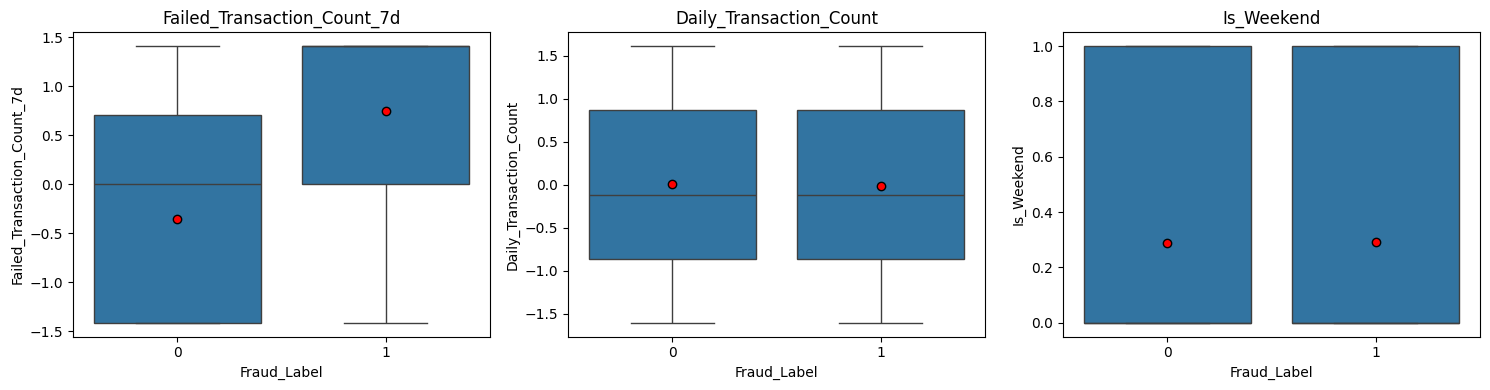

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "Failed_Transaction_Count_7d",
    "Daily_Transaction_Count",
    "Is_Weekend"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feat in enumerate(features):
    # print means
    print(f"\n{feat} means:")
    print(X_train_zz.groupby(y_train)[feat].mean())

    # plot
    sns.boxplot(
        x=y_train,
        y=X_train_zz[feat],
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "red",
            "markeredgecolor": "black",
            "markersize": 6
        },
        ax=axes[i]
    )

    axes[i].set_title(feat)

plt.tight_layout()
plt.show()


=== Failed_Transaction_Count_7d ===
Conditional probabilities:
Fraud_Label                         0         1
Failed_Transaction_Count_7d                    
-1.415461                    0.849695  0.150305
-0.709566                    0.845503  0.154497
-0.003671                    0.854814  0.145186
 0.702224                    0.843674  0.156326
 1.408119                    0.000125  0.999875

=== Daily_Transaction_Count ===
Fraud rate by bin:
bin
(-1.6059999999999999, -1.358]    0.331021
(-1.358, -1.111]                 0.314365
(-1.111, -0.616]                 0.325913
(-0.616, -0.369]                 0.313925
(-0.369, -0.122]                 0.325581
(-0.122, 0.373]                  0.323858
(0.373, 0.62]                    0.315401
(0.62, 1.114]                    0.320958
(1.114, 1.362]                   0.307692
(1.362, 1.609]                   0.319104
Name: y, dtype: float64

=== Is_Weekend ===
Conditional probabilities:
Fraud_Label         0         1
Is_Weekend           

C:\Users\Nikolina\AppData\Local\Temp\ipykernel_7236\3588693934.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_tmp.groupby("bin")["y"].mean()
C:\Users\Nikolina\AppData\Local\Temp\ipykernel_7236\3588693934.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df_tmp.groupby("bin")["y"].count()


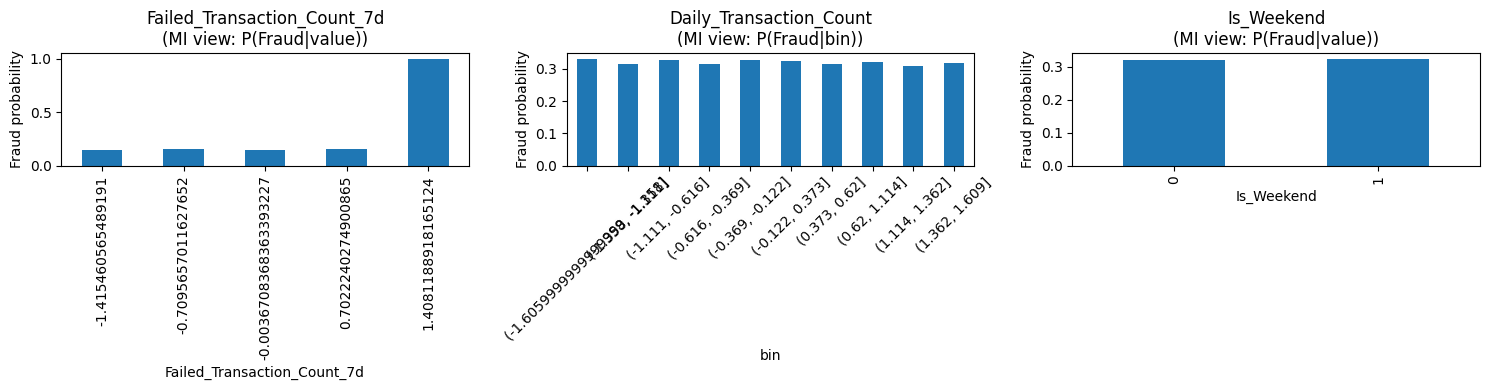

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

features = [
    "Failed_Transaction_Count_7d",
    "Daily_Transaction_Count",
    "Is_Weekend"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feat in enumerate(features):

    print(f"\n=== {feat} ===")

    if X_train_zz[feat].nunique() > 10:
        # continuous → binning
        df_tmp = pd.DataFrame({
            "feat": X_train_zz[feat],
            "y": y_train
        }).copy()

        df_tmp["bin"] = pd.qcut(df_tmp["feat"], q=10, duplicates='drop')

        grouped = df_tmp.groupby("bin")["y"].mean()
        counts = df_tmp.groupby("bin")["y"].count()

        print("Fraud rate by bin:")
        print(grouped)

        # plot
        grouped.plot(kind="bar", ax=axes[i])
        axes[i].set_title(f"{feat}\n(MI view: P(Fraud|bin))")
        axes[i].set_ylabel("Fraud probability")
        axes[i].tick_params(axis='x', rotation=45)

    else:
        # categorical / binary
        ct = pd.crosstab(X_train_zz[feat], y_train, normalize="index")

        print("Conditional probabilities:")
        print(ct)

        ct[1].plot(kind="bar", ax=axes[i])
        axes[i].set_title(f"{feat}\n(MI view: P(Fraud|value))")
        axes[i].set_ylabel("Fraud probability")

plt.tight_layout()
plt.show()

# 3. Relief metode

- **ReliefF, SURF, MultiSURF**
- instalirati prvo: ```pip install skrebate```

In [21]:
from skrebate import ReliefF, SURF, MultiSURF
import pandas as pd

# subsample jer je inače užasno sporo
df_train = X_train_zz.copy()
df_train["Fraud_Label"] = y_train

df_demo = df_train.sample(n=5000, random_state=42)

X_surf = df_demo.drop(columns=["Fraud_Label"]).copy()
y_surf = df_demo["Fraud_Label"].copy()

relieff = ReliefF(n_neighbors=100, n_features_to_select=10)
surf = SURF(n_features_to_select=10)
multisurf = MultiSURF(n_features_to_select=10)


relieff.fit(X_surf.values, y_surf.values)
relieff_scores = pd.Series(
    relieff.feature_importances_,
    index=X_surf.columns
).sort_values(ascending=False)

print("\n=== ReliefF ===")
print(relieff_scores.head(15))


surf.fit(X_surf.values, y_surf.values)
surf_scores = pd.Series(
    surf.feature_importances_,
    index=X_surf.columns
).sort_values(ascending=False)

print("\n=== SURF ===")
print(surf_scores.head(15))


multisurf.fit(X_surf.values, y_surf.values)
multisurf_scores = pd.Series(
    multisurf.feature_importances_,
    index=X_surf.columns
).sort_values(ascending=False)

print("\n=== MultiSURF ===")
print(multisurf_scores.head(15))


=== ReliefF ===
Failed_Transaction_Count_7d    0.281666
Risk_Score                     0.148397
DOW_sin                        0.020652
DOW_cos                        0.020652
Is_Weekend                     0.009554
TT_Bank Transfer               0.008776
TT_Online                      0.008598
MerchCat_Restaurants           0.008060
CT_Visa                        0.008010
Daily_Transaction_Count        0.007945
CT_Mastercard                  0.007874
Loc_Sydney                     0.007700
DT_Tablet                      0.007680
DT_Laptop                      0.007520
Txn_Burst                      0.007508
dtype: float64

=== SURF ===
Failed_Transaction_Count_7d     0.234879
Risk_Score                      0.133108
MerchCat_Restaurants            0.001181
Transaction_Distance            0.000734
Previous_Fraudulent_Activity    0.000155
IP_Address_Flag                -0.000350
Avg_Transaction_Amount_7d      -0.000869
Transaction_Amount             -0.000906
Amount_vs_Avg7d           

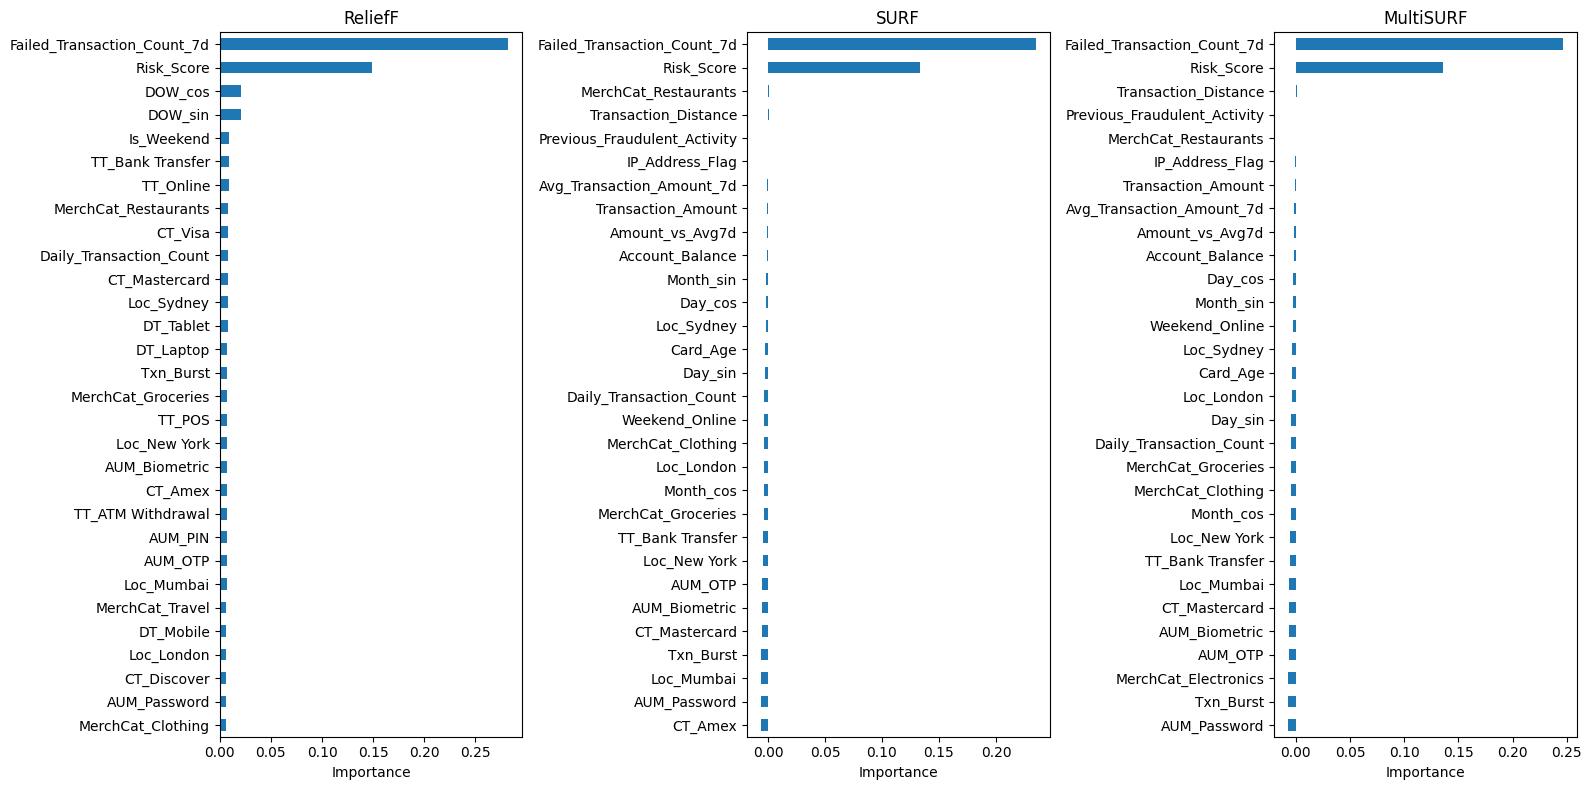

In [22]:
def plot_top_scores(scores, title, k=30, ax=None):
    topk = scores.head(k).sort_values()
    topk.plot(kind="barh", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Importance")

fig, axes = plt.subplots(1, 3, figsize=(16, 8))

plot_top_scores(relieff_scores, "ReliefF", k=30, ax=axes[0])
plot_top_scores(surf_scores, "SURF", k=30, ax=axes[1])
plot_top_scores(multisurf_scores, "MultiSURF", k=30, ax=axes[2])

plt.tight_layout()
plt.show()



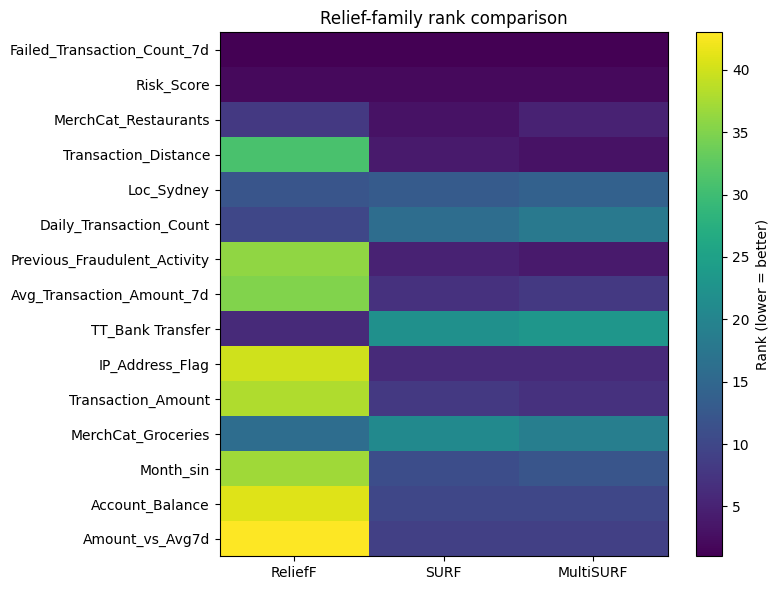

In [23]:
relief_combined = pd.DataFrame({
    "ReliefF": relieff_scores,
    "SURF": surf_scores,
    "MultiSURF": multisurf_scores
})

relief_ranks = relief_combined.rank(ascending=False, method="average")
top_features = relief_ranks.mean(axis=1).sort_values().head(15).index
rank_top = relief_ranks.loc[top_features]

plt.figure(figsize=(8, 6))
plt.imshow(rank_top, aspect="auto")
plt.colorbar(label="Rank (lower = better)")
plt.xticks(range(len(rank_top.columns)), rank_top.columns)
plt.yticks(range(len(rank_top.index)), rank_top.index)
plt.title("Relief-family rank comparison")
plt.tight_layout()
plt.show()

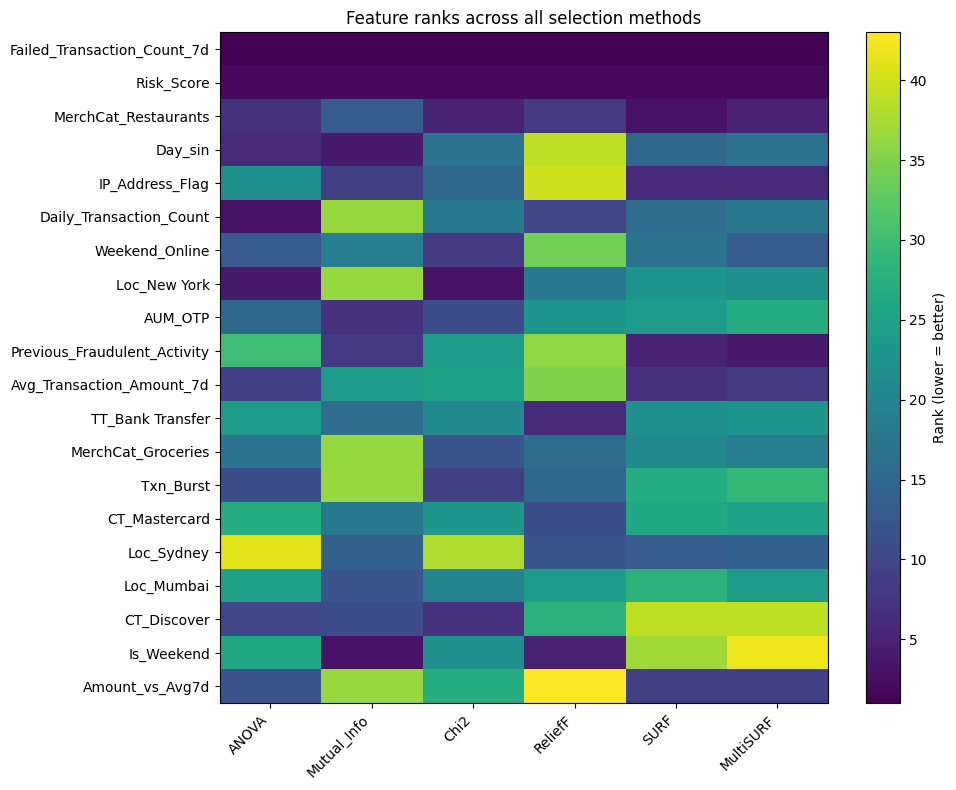

In [24]:
all_methods = pd.DataFrame({
    "ANOVA": anova_scores,
    "Mutual_Info": mi_scores,
    "Chi2": chi2_scores,
    "ReliefF": relieff_scores,
    "SURF": surf_scores,
    "MultiSURF": multisurf_scores
})

rank_all = all_methods.rank(ascending=False, method="average")
top_features = rank_all.mean(axis=1).sort_values().head(20).index
rank_top = rank_all.loc[top_features]

plt.figure(figsize=(10, 8))
plt.imshow(rank_top, aspect="auto")
plt.colorbar(label="Rank (lower = better)")
plt.xticks(range(len(rank_top.columns)), rank_top.columns, rotation=45, ha="right")
plt.yticks(range(len(rank_top.index)), rank_top.index)
plt.title("Feature ranks across all selection methods")
plt.tight_layout()
plt.show()

# 4. Multivarijatne metode
1. **mRMR**
- instalirati ```pip install mrmr-selection```

In [25]:
from mrmr import mrmr_classif

K = 15

selected_mrmr = mrmr_classif(X=X_train_zz, y=y_train, K=K)

print("Selected by mRMR (in order, most important first):")
for i, f in enumerate(selected_mrmr, 1):
    print(f"{i:2d}. {f}")




100%|██████████| 15/15 [00:02<00:00,  6.79it/s]

Selected by mRMR (in order, most important first):
 1. Failed_Transaction_Count_7d
 2. Risk_Score
 3. MerchCat_Restaurants
 4. CT_Discover
 5. TT_POS
 6. DT_Tablet
 7. Avg_Transaction_Amount_7d
 8. Loc_New York
 9. AUM_PIN
10. Day_sin
11. Daily_Transaction_Count
12. Account_Balance
13. IP_Address_Flag
14. Is_Weekend
15. Month_cos


# 5. Wrapper - Sequential Forward Selection with Logistic Regression

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import f1_score, classification_report



base_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

sfs = SequentialFeatureSelector(
    estimator=base_model,
    n_features_to_select=10,
    direction="forward",
    scoring="f1",
    cv=5,
    n_jobs=-1
)

sfs.fit(X_train_zz, y_train)

selected_features = X_train_zz.columns[sfs.get_support()].tolist()

print("\nSelected features (SFS):")
for i, f in enumerate(selected_features, 1):
    print(f"{i:2d}. {f}")



X_train_sel = X_train_zz[selected_features]
X_test_sel = X_test_zz[selected_features]

base_model.fit(X_train_sel, y_train)
y_pred = base_model.predict(X_test_sel)

print("\nClassification report on selected features:")
print(classification_report(y_test, y_pred))


Selected features (SFS):
 1. Transaction_Amount
 2. Failed_Transaction_Count_7d
 3. Risk_Score
 4. Loc_Mumbai
 5. MerchCat_Groceries
 6. CT_Mastercard
 7. AUM_OTP
 8. AUM_Password
 9. Month_sin
10. DOW_sin

Classification report on selected features:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      6786
           1       0.65      0.80      0.72      3214

    accuracy                           0.80     10000
   macro avg       0.77      0.80      0.78     10000
weighted avg       0.81      0.80      0.80     10000



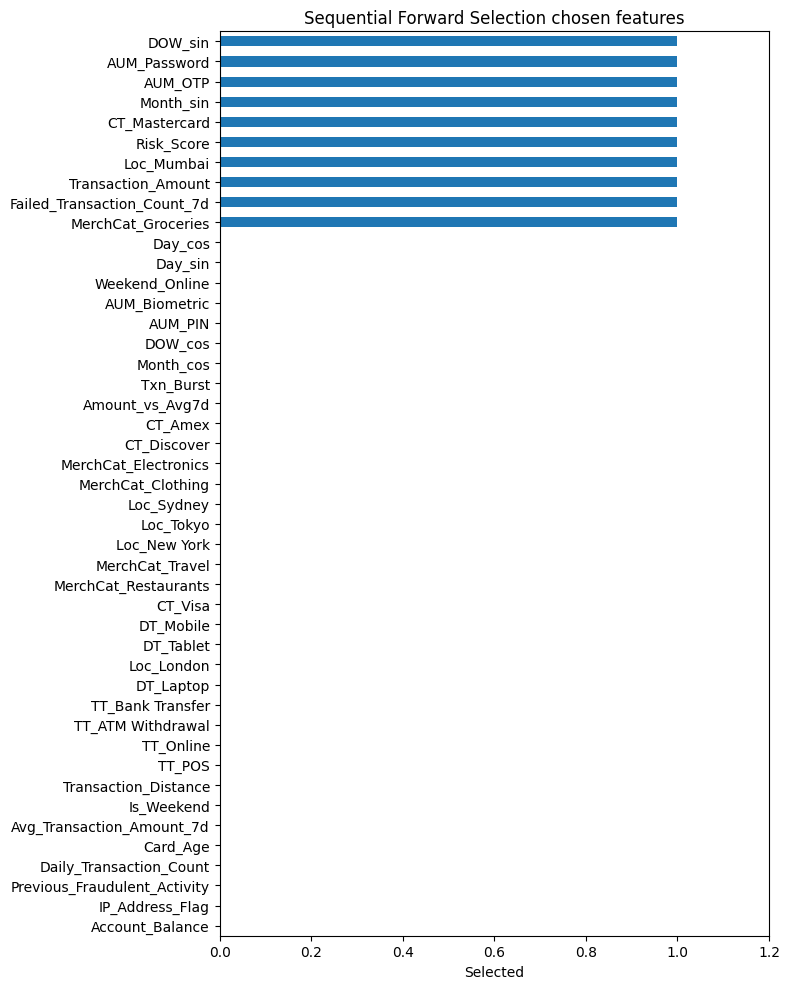

In [30]:
selection_mask = pd.Series(0, index=X.columns)
selection_mask[selected_features] = 1
selection_mask = selection_mask.sort_values(ascending=True)

plt.figure(figsize=(8, 10))
selection_mask.plot(kind="barh")
plt.title("Sequential Forward Selection chosen features")
plt.xlabel("Selected")
plt.xlim(0, 1.2)
plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import accuracy_score, f1_score

# baseline on all features
baseline_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)
baseline_model.fit(X_train_zz, y_train)
y_pred_all = baseline_model.predict(X_test_zz)

acc_all = accuracy_score(y_test, y_pred_all)
acc_sel = accuracy_score(y_test, y_pred)

f1_all = f1_score(y_test, y_pred_all)
f1_sel = f1_score(y_test, y_pred)

print(f"Accuracy with all features     : {acc_all:.4f}")
print(f"Accuracy with selected features: {acc_sel:.4f}")
print(f"F1 with all features     : {f1_all:.4f}")
print(f"F1 with selected features: {f1_sel:.4f}")
print(f"Number of all features   : {X.shape[1]}")
print(f"Number of selected feats : {len(selected_features)}")

Accuracy with all features     : 0.7981
Accuracy with selected features: 0.7978
F1 with all features     : 0.7177
F1 with selected features: 0.7169
Number of all features   : 45
Number of selected feats : 10


# 6. EMBEDDED

1. Lasso
2. Random Forest


Top absolute coefficients:
Risk_Score                     5.481426
Failed_Transaction_Count_7d    1.893759
Weekend_Online                 0.054312
Loc_New York                   0.038567
MerchCat_Groceries             0.030136
MerchCat_Restaurants           0.027276
AUM_Biometric                  0.026342
Day_cos                        0.020583
Card_Age                       0.019966
MerchCat_Electronics           0.019022
Is_Weekend                     0.018354
Transaction_Distance           0.017955
AUM_PIN                        0.017552
TT_ATM Withdrawal              0.017424
Account_Balance                0.017325
dtype: float64

Selected by L1 logistic regression:
 1. Risk_Score
 2. Failed_Transaction_Count_7d
 3. Weekend_Online
 4. Loc_New York
 5. MerchCat_Groceries
 6. MerchCat_Restaurants
 7. AUM_Biometric
 8. Day_cos
 9. Card_Age
10. MerchCat_Electronics
11. Is_Weekend
12. Transaction_Distance
13. AUM_PIN
14. TT_ATM Withdrawal
15. Account_Balance
16. TT_POS
17. CT_Amex
18. 

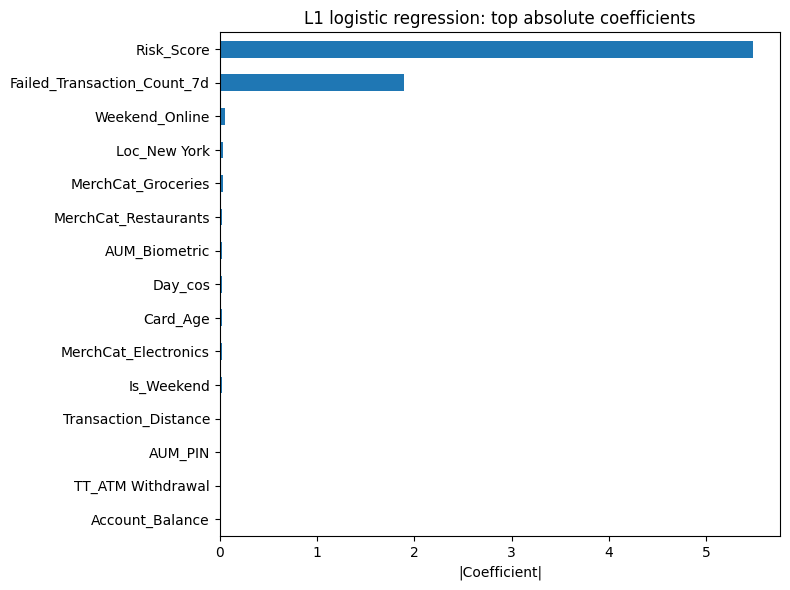

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report



# ============================================================
# L1 logistic regression as embedded selector
# ============================================================

l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",   # robust for smaller / medium cases; good for L1
    C=0.1,                # stronger regularization; try 0.01, 0.1, 1.0
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

l1_model.fit(X_train_zz, y_train)

coef_series = pd.Series(np.abs(l1_model.coef_[0]), index=X.columns).sort_values(ascending=False)

print("\nTop absolute coefficients:")
print(coef_series.head(15))

selected_l1 = coef_series[coef_series > 1e-8].index.tolist()

print("\nSelected by L1 logistic regression:")
for i, f in enumerate(selected_l1, 1):
    print(f"{i:2d}. {f}")


X_train_sel = X_train_zz[selected_l1]
X_test_sel = X_test_zz[selected_l1]

final_l1 = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

final_l1.fit(X_train_sel, y_train)
y_pred_sel = final_l1.predict(X_test_sel)

baseline = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)
baseline.fit(X_train_zz, y_train)
y_pred_all = baseline.predict(X_test_zz)

print(f"\nF1 with all features     : {f1_score(y_test, y_pred_all):.4f}")
print(f"F1 with selected features: {f1_score(y_test, y_pred_sel):.4f}")

plt.figure(figsize=(8, 6))
coef_series.head(15).sort_values().plot(kind="barh")
plt.title("L1 logistic regression: top absolute coefficients")
plt.xlabel("|Coefficient|")
plt.tight_layout()
plt.show()


Top RF importances:
Failed_Transaction_Count_7d    0.515700
Risk_Score                     0.376286
Transaction_Distance           0.009198
Transaction_Amount             0.008901
Account_Balance                0.008812
Amount_vs_Avg7d                0.008735
Avg_Transaction_Amount_7d      0.008669
Card_Age                       0.008366
Day_sin                        0.005675
Daily_Transaction_Count        0.005027
Day_cos                        0.004774
Month_cos                      0.003642
Month_sin                      0.003627
DOW_sin                        0.003145
DOW_cos                        0.002290
dtype: float64

Selected by Random Forest (importance > median):
 1. Failed_Transaction_Count_7d
 2. Risk_Score
 3. Transaction_Distance
 4. Transaction_Amount
 5. Account_Balance
 6. Amount_vs_Avg7d
 7. Avg_Transaction_Amount_7d
 8. Card_Age
 9. Day_sin
10. Daily_Transaction_Count
11. Day_cos
12. Month_cos
13. Month_sin
14. DOW_sin
15. DOW_cos
16. AUM_Password
17. CT_Amex
18.

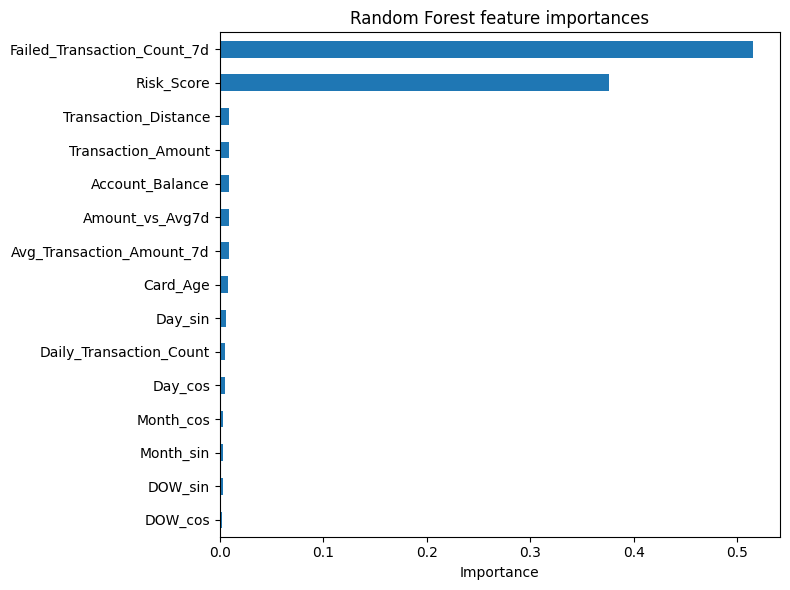

In [35]:
from sklearn.ensemble import RandomForestClassifier


# ============================================================
# Random Forest embedded importance
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train_zz, y_train)

rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nTop RF importances:")
print(rf_importances.head(15))

selected_rf = rf_importances[rf_importances > rf_importances.median()].index.tolist()

print("\nSelected by Random Forest (importance > median):")
for i, f in enumerate(selected_rf, 1):
    print(f"{i:2d}. {f}")



X_train_sel = X_train_zz[selected_rf]
X_test_sel = X_test_zz[selected_rf]

rf_sel = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_sel.fit(X_train_sel, y_train)
y_pred_sel = rf_sel.predict(X_test_sel)

rf_all = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_all.fit(X_train_zz, y_train)
y_pred_all = rf_all.predict(X_test_zz)

print(f"\nF1 with all features     : {f1_score(y_test, y_pred_all):.4f}")
print(f"F1 with selected features: {f1_score(y_test, y_pred_sel):.4f}")

plt.figure(figsize=(8, 6))
rf_importances.head(15).sort_values().plot(kind="barh")
plt.title("Random Forest feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()